In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
arbo = pd.read_csv('trt_con_d15n.csv')

arbo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 40 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   %N                                                           1270 non-null   float64
 1   %C                                                           1261 non-null   float64
 2   d15N_Collagen                                                1364 non-null   float64
 3   Metallurgy                                                   952 non-null    object 
 4   Cultural_Horizon                                             1064 non-null   object 
 5   Nr_of_Seeds_Collagen_d13C_and_d15N                           1276 non-null   object 
 6   IRMS_Lab_Institution_Stable_Carbon_and_Nitrogen_Measurement  869 non-null    object 
 7   Absolute_Chronology                                          1254 non-null   o

In [4]:
print("\n" + "="*50)
print("ESTADÍSTICAS BÁSICAS")
print("="*50)

# Variables numéricas de interés
vars_numericas = ['IRMS_d13C_Collagen', 'd15N_Collagen', 'Latitude_N', 
                  'Longitude_E', 'Min_Year', 'Max_Year', 'antiguedad_kBP']

vars_existentes = [v for v in vars_numericas if v in arbo.columns]

print(arbo[vars_existentes].describe())


ESTADÍSTICAS BÁSICAS
       IRMS_d13C_Collagen  d15N_Collagen   Latitude_N  Longitude_E  \
count         1364.000000    1364.000000  1359.000000  1359.000000   
mean           -22.976774       2.918724    39.204117    18.471626   
std              3.644027       2.732856     2.909522    11.560524   
min            -30.100000      -4.200000    29.240000    -9.440000   
25%            -24.200000       1.097500    37.062972    12.715642   
50%            -23.500000       2.600000    40.418397    22.541419   
75%            -22.700000       4.520000    41.885726    25.161653   
max              0.640000      15.400000    44.413343    41.058576   

          Min_Year     Max_Year  antiguedad_kBP  
count  1306.000000  1306.000000     1306.000000  
mean  -2253.470904 -1815.228943       -2.034350  
std    2045.731873  1820.936221        1.924541  
min   -7956.000000 -7058.000000       -7.507000  
25%   -3190.000000 -3130.000000       -3.160000  
50%   -2130.000000 -1414.000000       -1.772000


DISTRIBUCIÓN DE DOMESTICATED
Domesticated
yes    1346
Yes      17
No        1
Name: count, dtype: int64

Porcentajes:
Domesticated
yes    98.680352
Yes     1.246334
No      0.073314
Name: proportion, dtype: float64


C:\Users\David\AppData\Local\Temp\ipykernel_16392\81362409.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=arbo, x='Domesticated', palette='Set2')


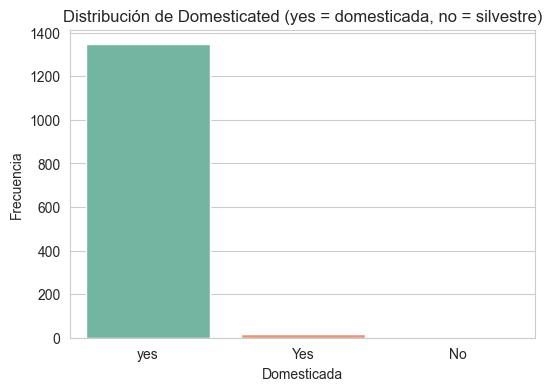

In [5]:
print("\n" + "="*50)
print("DISTRIBUCIÓN DE DOMESTICATED")
print("="*50)

print(arbo['Domesticated'].value_counts())
print(f"\nPorcentajes:")
print(arbo['Domesticated'].value_counts(normalize=True) * 100)

# Gráfico de barras
plt.figure(figsize=(6, 4))
sns.countplot(data=arbo, x='Domesticated', palette='Set2')
plt.title('Distribución de Domesticated (yes = domesticada, no = silvestre)')
plt.xlabel('Domesticada')
plt.ylabel('Frecuencia')
plt.show()


δ13C SEGÚN DOMESTICATED
               count       mean       std    min    25%    50%    75%    max
Domesticated                                                                
No               1.0 -28.090000       NaN -28.09 -28.09 -28.09 -28.09 -28.09
Yes             17.0 -25.238824  1.849026 -28.12 -26.24 -25.76 -23.92 -20.99
yes           1346.0 -22.944406  3.651138 -30.10 -24.16 -23.50 -22.70   0.64


C:\Users\David\AppData\Local\Temp\ipykernel_16392\3419624310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=arbo, x='Domesticated', y='IRMS_d13C_Collagen', palette='Set2')


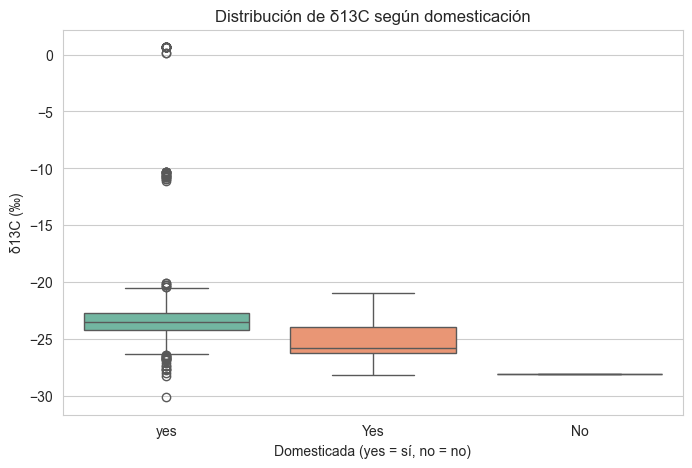

In [6]:
print("\n" + "="*50)
print("δ13C SEGÚN DOMESTICATED")
print("="*50)

# Estadísticas por grupo
print(arbo.groupby('Domesticated')['IRMS_d13C_Collagen'].describe())

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=arbo, x='Domesticated', y='IRMS_d13C_Collagen', palette='Set2')
plt.title('Distribución de δ13C según domesticación')
plt.xlabel('Domesticada (yes = sí, no = no)')
plt.ylabel('δ13C (‰)')
plt.show()


δ15N SEGÚN DOMESTICATED


C:\Users\David\AppData\Local\Temp\ipykernel_16392\3119549054.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=arbo, x='Domesticated', y='d15N_Collagen', palette='Set2')


               count      mean       std   min     25%   50%     75%    max
Domesticated                                                               
No               1.0  3.020000       NaN  3.02  3.0200  3.02  3.0200   3.02
Yes             17.0  0.029412  1.693238 -2.78 -0.8600 -0.17  0.8900   3.21
yes           1346.0  2.955141  2.725343 -4.20  1.1925  2.62  4.5625  15.40


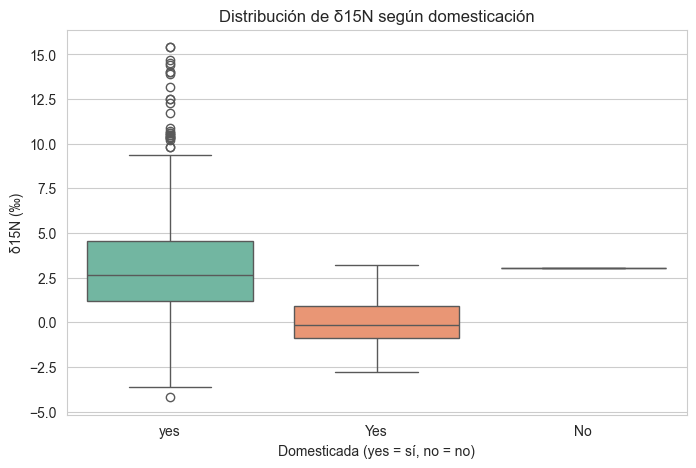

In [7]:
print("\n" + "="*50)
print("δ15N SEGÚN DOMESTICATED")
print("="*50)

# Estadísticas por grupo
print(arbo.groupby('Domesticated')['d15N_Collagen'].describe())

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=arbo, x='Domesticated', y='d15N_Collagen', palette='Set2')
plt.title('Distribución de δ15N según domesticación')
plt.xlabel('Domesticada (yes = sí, no = no)')
plt.ylabel('δ15N (‰)')
plt.show()


EVOLUCIÓN DE δ13C A LO LARGO DEL TIEMPO


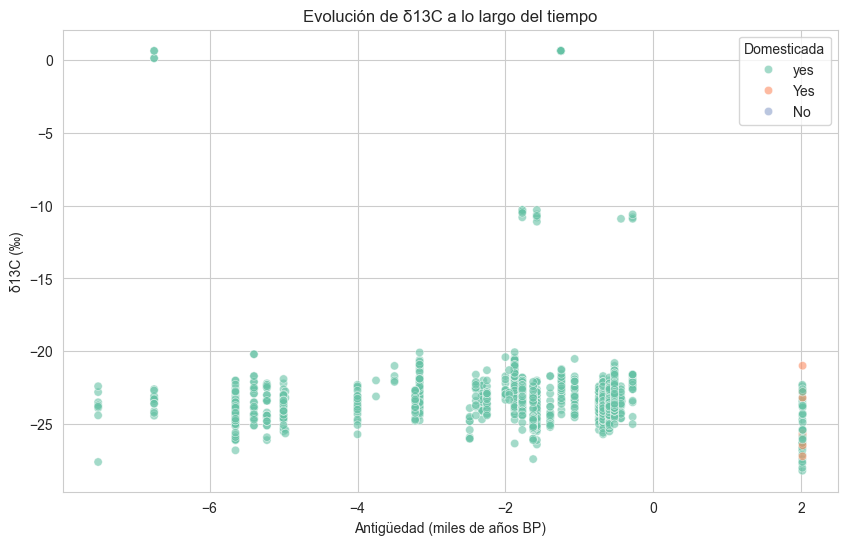

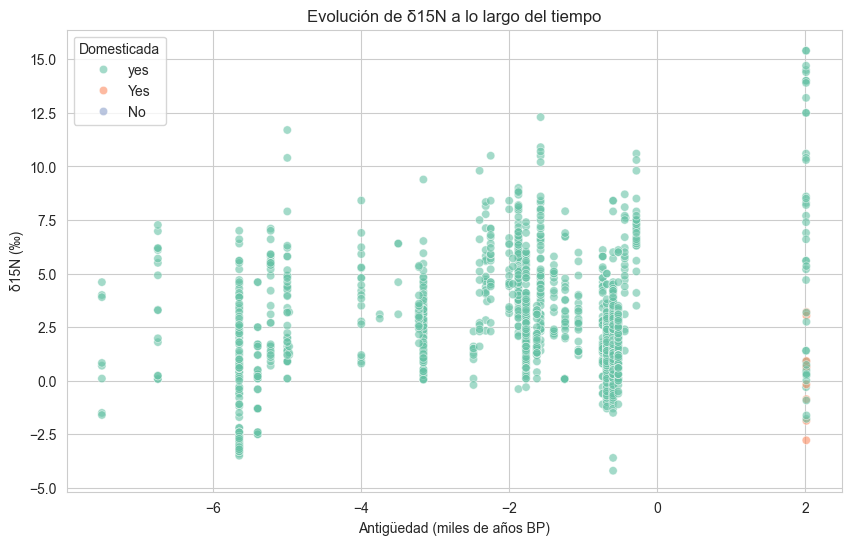

In [8]:
print("\n" + "="*50)
print("EVOLUCIÓN DE δ13C A LO LARGO DEL TIEMPO")
print("="*50)

# Scatter plot con línea de tendencia
plt.figure(figsize=(10, 6))
sns.scatterplot(data=arbo, x='antiguedad_kBP', y='IRMS_d13C_Collagen', 
                hue='Domesticated', alpha=0.6, palette='Set2')
plt.title('Evolución de δ13C a lo largo del tiempo')
plt.xlabel('Antigüedad (miles de años BP)')
plt.ylabel('δ13C (‰)')
plt.legend(title='Domesticada')
plt.show()

# Evolución de δ15N
plt.figure(figsize=(10, 6))
sns.scatterplot(data=arbo, x='antiguedad_kBP', y='d15N_Collagen', 
                hue='Domesticated', alpha=0.6, palette='Set2')
plt.title('Evolución de δ15N a lo largo del tiempo')
plt.xlabel('Antigüedad (miles de años BP)')
plt.ylabel('δ15N (‰)')
plt.legend(title='Domesticada')
plt.show()


MATRIZ DE CORRELACIONES


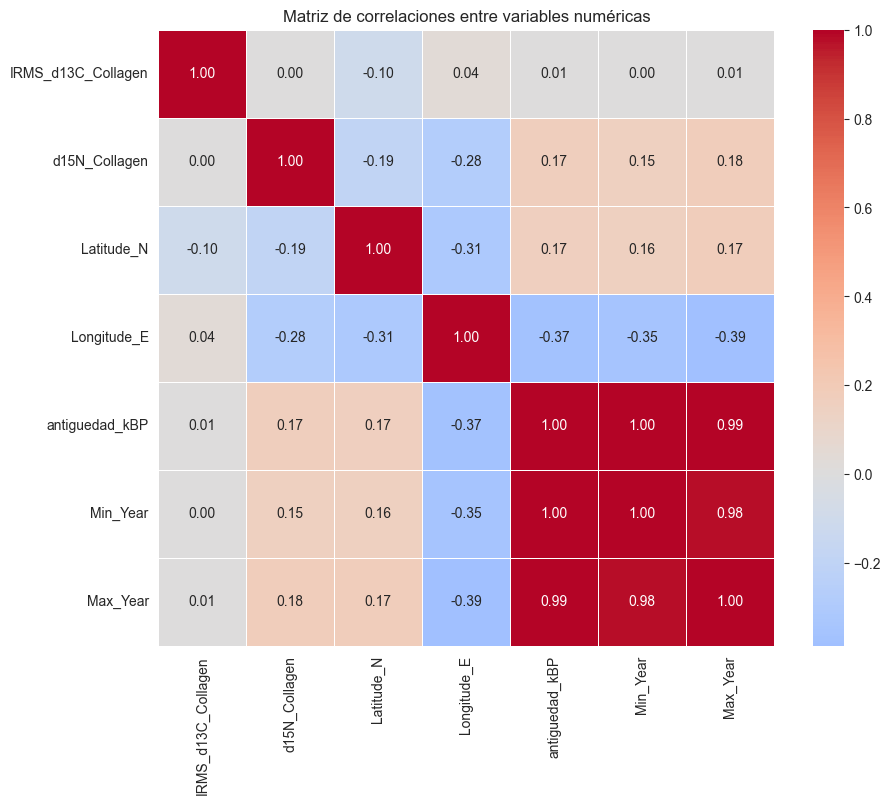


Correlación de variables con Domesticated:
Domesticated_num      1.000000
d15N_Collagen         0.115274
Latitude_N            0.114029
IRMS_d13C_Collagen    0.076840
Longitude_E          -0.102891
Min_Year             -0.174008
Max_Year             -0.175434
antiguedad_kBP       -0.175477
Name: Domesticated_num, dtype: float64


In [9]:
print("\n" + "="*50)
print("MATRIZ DE CORRELACIONES")
print("="*50)

# Seleccionar variables numéricas para correlación
vars_correlacion = ['IRMS_d13C_Collagen', 'd15N_Collagen', 'Latitude_N', 
                    'Longitude_E', 'antiguedad_kBP', 'Min_Year', 'Max_Year']

vars_corr_exist = [v for v in vars_correlacion if v in arbo.columns]

# Matriz de correlación
corr_matrix = arbo[vars_corr_exist].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()

# Correlaciones con la variable objetivo (convertir Domesticated a numérica)
arbo['Domesticated_num'] = (arbo['Domesticated'] == 'yes').astype(int)
print("\nCorrelación de variables con Domesticated:")
print(arbo[vars_corr_exist + ['Domesticated_num']].corr()['Domesticated_num'].sort_values(ascending=False))

Interpretación

| Variable | Correlación | ¿Qué significa? |
|----------|-------------|----------------|
| `antiguedad_kBP` | **-0.175** | Las plantas más antiguas tienden a ser `'yes'` (domesticadas) |
| `Min_Year` / `Max_Year` | **-0.174 / -0.175** | Consistente con lo anterior |
| `d15N_Collagen` | **0.115** | Relación positiva débil |
| `Latitude_N` | **0.114** | Relación positiva débil |
| `Longitude_E` | **-0.103** | Relación negativa débil |

In [10]:
# Selección columnas útiles
# ============================================
# AÑADIR COLUMNAS ADICIONALES
# ============================================

# Lista actualizada de columnas útiles
columnas_utiles = [
    # Target
    'Domesticated',
    
    # Predictoras numéricas
    'IRMS_d13C_Collagen',
    'd15N_Collagen',
    'Latitude_N',
    'Longitude_E',
    'antiguedad_kBP',
    'es_muy_antigua',
    'Nr_of_Samples_Collagen_d13C_and_d15N',  # NUEVA
    
    # Predictoras categóricas
    'General_Category_or_Family',
    'C4_Plant',
    'Sampled_Element',
    'Cultural_Horizon',      # NUEVA
    'Species',               # NUEVA
    'Site_Description'       # NUEVA
]

# Ver qué columnas existen
columnas_existentes = [col for col in columnas_utiles if col in arbo.columns]
columnas_faltantes = [col for col in columnas_utiles if col not in arbo.columns]

print("✅ Columnas SELECCIONADAS para el modelo:")
for col in columnas_existentes:
    nulos = arbo[col].isnull().sum()
    print(f"   - {col} ({nulos} nulos)")

if columnas_faltantes:
    print(f"\n⚠️ Columnas NO ENCONTRADAS: {columnas_faltantes}")

# Crear DataFrame reducido
arbo_ml = arbo[columnas_existentes].copy()

print(f"\n📊 Shape final: {arbo_ml.shape}")
print(f"   {arbo_ml.shape[0]} filas × {arbo_ml.shape[1]} columnas")

✅ Columnas SELECCIONADAS para el modelo:
   - Domesticated (0 nulos)
   - IRMS_d13C_Collagen (0 nulos)
   - d15N_Collagen (0 nulos)
   - Latitude_N (5 nulos)
   - Longitude_E (5 nulos)
   - antiguedad_kBP (58 nulos)
   - es_muy_antigua (0 nulos)
   - Nr_of_Samples_Collagen_d13C_and_d15N (0 nulos)
   - General_Category_or_Family (1 nulos)
   - C4_Plant (1 nulos)
   - Sampled_Element (87 nulos)
   - Cultural_Horizon (300 nulos)
   - Species (8 nulos)
   - Site_Description (108 nulos)

📊 Shape final: (1364, 14)
   1364 filas × 14 columnas


In [11]:
arbo_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Domesticated                          1364 non-null   object 
 1   IRMS_d13C_Collagen                    1364 non-null   float64
 2   d15N_Collagen                         1364 non-null   float64
 3   Latitude_N                            1359 non-null   float64
 4   Longitude_E                           1359 non-null   float64
 5   antiguedad_kBP                        1306 non-null   float64
 6   es_muy_antigua                        1364 non-null   int64  
 7   Nr_of_Samples_Collagen_d13C_and_d15N  1364 non-null   float64
 8   General_Category_or_Family            1363 non-null   object 
 9   C4_Plant                              1363 non-null   object 
 10  Sampled_Element                       1277 non-null   object 
 11  Cultural_Horizon 

Resumen

| Tipo | Columnas | Cantidad |
|------|----------|----------|
| **Target** | `Domesticated` | 1 |
| **Numéricas** | `IRMS_d13C_Collagen`, `d15N_Collagen`, `Latitude_N`, `Longitude_E`, `antiguedad_kBP`, `es_muy_antigua`, `Nr_of_Samples_Collagen_d13C_and_d15N` | 7 |
| **Categóricas** | `General_Category_or_Family`, `C4_Plant`, `Sampled_Element`, `Cultural_Horizon`, `Species`, `Site_Description` | 6 |

---

In [12]:
# Ver estadísticas básicas de variables numéricas
print("="*50)
print("1. ESTADÍSTICAS BÁSICAS - VARIABLES NUMÉRICAS")
print("="*50)

vars_numericas = ['IRMS_d13C_Collagen', 'd15N_Collagen', 'Latitude_N', 
                  'Longitude_E', 'antiguedad_kBP', 'Nr_of_Samples_Collagen_d13C_and_d15N']

print(arbo_ml[vars_numericas].describe())

1. ESTADÍSTICAS BÁSICAS - VARIABLES NUMÉRICAS
       IRMS_d13C_Collagen  d15N_Collagen   Latitude_N  Longitude_E  \
count         1364.000000    1364.000000  1359.000000  1359.000000   
mean           -22.976774       2.918724    39.204117    18.471626   
std              3.644027       2.732856     2.909522    11.560524   
min            -30.100000      -4.200000    29.240000    -9.440000   
25%            -24.200000       1.097500    37.062972    12.715642   
50%            -23.500000       2.600000    40.418397    22.541419   
75%            -22.700000       4.520000    41.885726    25.161653   
max              0.640000      15.400000    44.413343    41.058576   

       antiguedad_kBP  Nr_of_Samples_Collagen_d13C_and_d15N  
count     1306.000000                                1364.0  
mean        -2.034350                                   1.0  
std          1.924541                                   0.0  
min         -7.507000                                   1.0  
25%         -


2. DISTRIBUCIÓN DE DOMESTICATED
Domesticated
yes    1346
Yes      17
No        1
Name: count, dtype: int64

Porcentajes:
Domesticated
yes    98.680352
Yes     1.246334
No      0.073314
Name: proportion, dtype: float64


C:\Users\David\AppData\Local\Temp\ipykernel_16392\290639039.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=arbo_ml, x='Domesticated', palette='Set2')


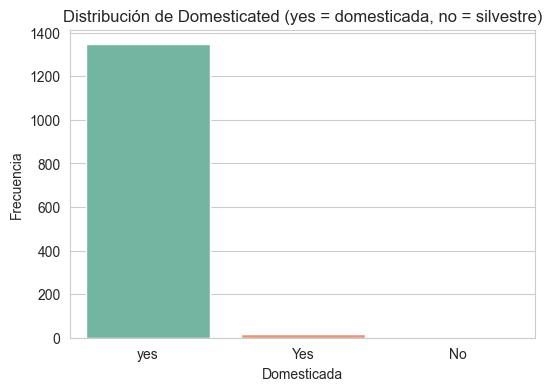

In [13]:
print("\n" + "="*50)
print("2. DISTRIBUCIÓN DE DOMESTICATED")
print("="*50)

print(arbo_ml['Domesticated'].value_counts())
print(f"\nPorcentajes:")
print(arbo_ml['Domesticated'].value_counts(normalize=True) * 100)

# Gráfico
plt.figure(figsize=(6, 4))
sns.countplot(data=arbo_ml, x='Domesticated', palette='Set2')
plt.title('Distribución de Domesticated (yes = domesticada, no = silvestre)')
plt.xlabel('Domesticada')
plt.ylabel('Frecuencia')
plt.show()


3. DISTRIBUCIÓN DE ISÓTOPOS


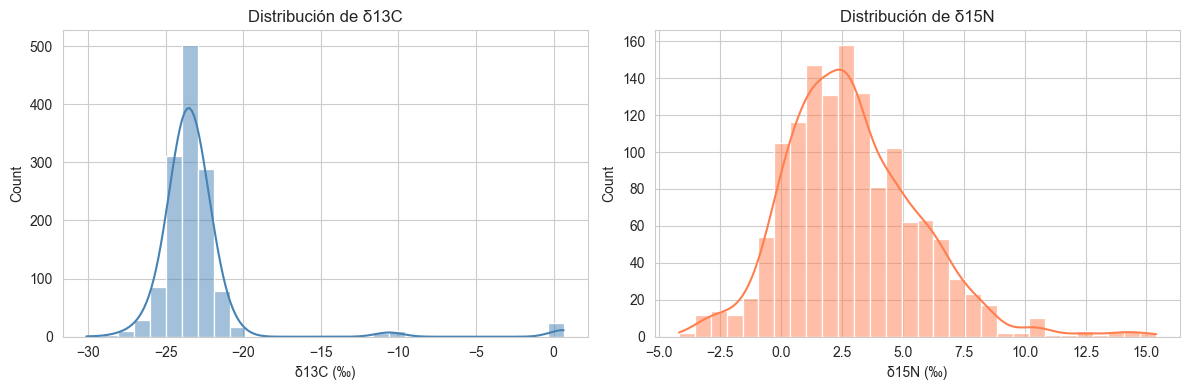

In [14]:
print("\n" + "="*50)
print("3. DISTRIBUCIÓN DE ISÓTOPOS")
print("="*50)

# Histograma de δ13C
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=arbo_ml, x='IRMS_d13C_Collagen', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de δ13C')
axes[0].set_xlabel('δ13C (‰)')

sns.histplot(data=arbo_ml, x='d15N_Collagen', bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución de δ15N')
axes[1].set_xlabel('δ15N (‰)')

plt.tight_layout()
plt.show()


4. ISÓTOPOS SEGÚN DOMESTICATED

📊 δ13C por Domesticated:
               count       mean       std    min    25%    50%    75%    max
Domesticated                                                                
No               1.0 -28.090000       NaN -28.09 -28.09 -28.09 -28.09 -28.09
Yes             17.0 -25.238824  1.849026 -28.12 -26.24 -25.76 -23.92 -20.99
yes           1346.0 -22.944406  3.651138 -30.10 -24.16 -23.50 -22.70   0.64

📊 δ15N por Domesticated:
               count      mean       std   min     25%   50%     75%    max
Domesticated                                                               
No               1.0  3.020000       NaN  3.02  3.0200  3.02  3.0200   3.02
Yes             17.0  0.029412  1.693238 -2.78 -0.8600 -0.17  0.8900   3.21
yes           1346.0  2.955141  2.725343 -4.20  1.1925  2.62  4.5625  15.40


C:\Users\David\AppData\Local\Temp\ipykernel_16392\1090421513.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=arbo_ml, x='Domesticated', y='IRMS_d13C_Collagen', ax=axes[0], palette='Set2')
C:\Users\David\AppData\Local\Temp\ipykernel_16392\1090421513.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=arbo_ml, x='Domesticated', y='d15N_Collagen', ax=axes[1], palette='Set2')


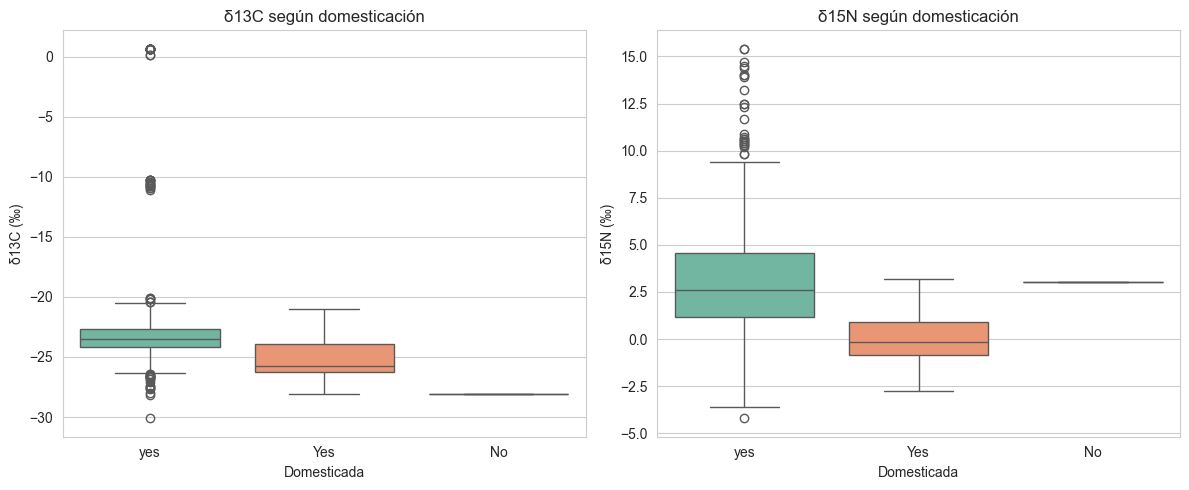

In [15]:
print("\n" + "="*50)
print("4. ISÓTOPOS SEGÚN DOMESTICATED")
print("="*50)

# Estadísticas por grupo
print("\n📊 δ13C por Domesticated:")
print(arbo_ml.groupby('Domesticated')['IRMS_d13C_Collagen'].describe())

print("\n📊 δ15N por Domesticated:")
print(arbo_ml.groupby('Domesticated')['d15N_Collagen'].describe())

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=arbo_ml, x='Domesticated', y='IRMS_d13C_Collagen', ax=axes[0], palette='Set2')
axes[0].set_title('δ13C según domesticación')
axes[0].set_xlabel('Domesticada')
axes[0].set_ylabel('δ13C (‰)')

sns.boxplot(data=arbo_ml, x='Domesticated', y='d15N_Collagen', ax=axes[1], palette='Set2')
axes[1].set_title('δ15N según domesticación')
axes[1].set_xlabel('Domesticada')
axes[1].set_ylabel('δ15N (‰)')

plt.tight_layout()
plt.show()


5. EVOLUCIÓN TEMPORAL DE ISÓTOPOS


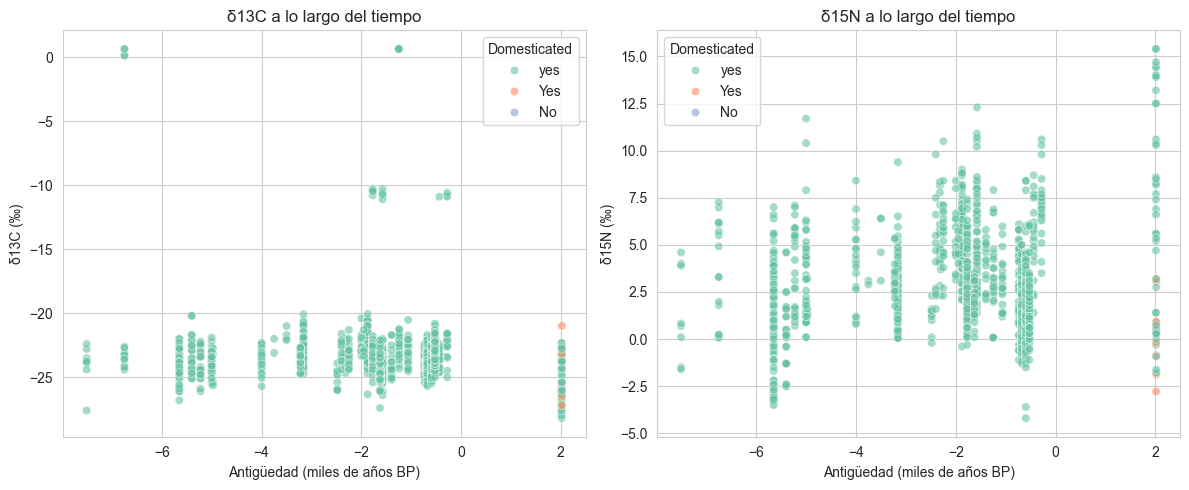

In [16]:
print("\n" + "="*50)
print("5. EVOLUCIÓN TEMPORAL DE ISÓTOPOS")
print("="*50)

# Scatter plot: antigüedad vs δ13C
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=arbo_ml, x='antiguedad_kBP', y='IRMS_d13C_Collagen', 
                hue='Domesticated', alpha=0.6, palette='Set2', ax=axes[0])
axes[0].set_title('δ13C a lo largo del tiempo')
axes[0].set_xlabel('Antigüedad (miles de años BP)')
axes[0].set_ylabel('δ13C (‰)')

sns.scatterplot(data=arbo_ml, x='antiguedad_kBP', y='d15N_Collagen', 
                hue='Domesticated', alpha=0.6, palette='Set2', ax=axes[1])
axes[1].set_title('δ15N a lo largo del tiempo')
axes[1].set_xlabel('Antigüedad (miles de años BP)')
axes[1].set_ylabel('δ15N (‰)')

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*50)
print("6. VARIABLES CATEGÓRICAS - TOP 10")
print("="*50)

categoricas = ['General_Category_or_Family', 'C4_Plant', 'Sampled_Element', 
               'Cultural_Horizon', 'Species']

for col in categoricas:
    if col in arbo_ml.columns:
        print(f"\n🔹 {col}:")
        print(arbo_ml[col].value_counts().head(10))


6. VARIABLES CATEGÓRICAS - TOP 10

🔹 General_Category_or_Family:
General_Category_or_Family
Poaceae          1181
Fabaceae          171
Oleaceae            2
Fagaceae            2
Moraceae            2
Linaceae            1
Rosaceae            1
Anacardiaceae       1
Juglandaceae        1
Lythraceae          1
Name: count, dtype: int64

🔹 C4_Plant:
C4_Plant
no     1347
yes      16
Name: count, dtype: int64

🔹 Sampled_Element:
Sampled_Element
Charred Seed     419
Seed             397
Grain            218
Charred Plant     95
Charred grain     86
Charred seed      39
Charred plant     16
Charred pulse      5
Shell              1
Skin               1
Name: count, dtype: int64

🔹 Cultural_Horizon:
Cultural_Horizon
Latial                                  362
Late Bronze Age                         119
Late Chalcolithic                       112
El Algar                                103
Middle Bronze Age                        55
Early Bronze Age                         45
Early Bronze Ag


7. MATRIZ DE CORRELACIONES


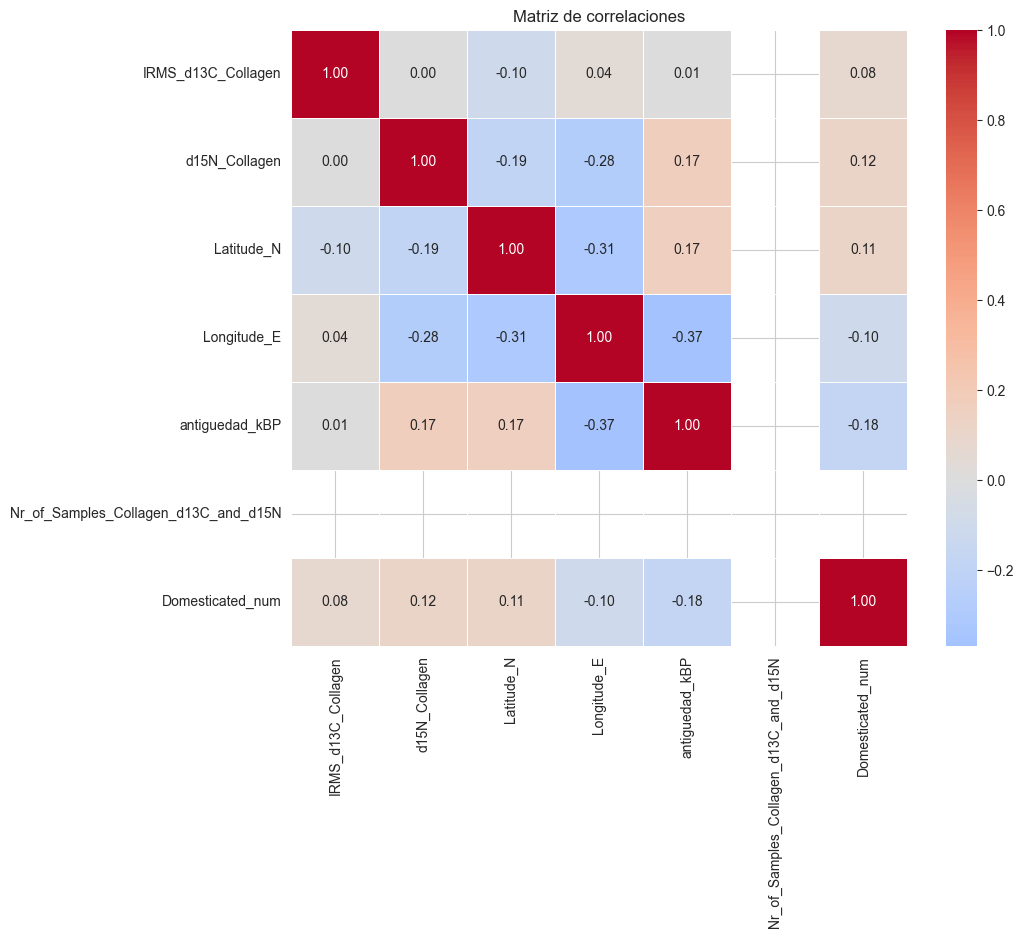


📊 Correlación con Domesticated:
Domesticated_num                        1.000000
d15N_Collagen                           0.115274
Latitude_N                              0.114029
IRMS_d13C_Collagen                      0.076840
Longitude_E                            -0.102891
antiguedad_kBP                         -0.175477
Nr_of_Samples_Collagen_d13C_and_d15N         NaN
Name: Domesticated_num, dtype: float64


In [18]:
print("\n" + "="*50)
print("7. MATRIZ DE CORRELACIONES")
print("="*50)

# Convertir Domesticated a numérico
arbo_ml['Domesticated_num'] = (arbo_ml['Domesticated'] == 'yes').astype(int)

# Correlaciones
vars_corr = ['IRMS_d13C_Collagen', 'd15N_Collagen', 'Latitude_N', 
             'Longitude_E', 'antiguedad_kBP', 'Nr_of_Samples_Collagen_d13C_and_d15N']

vars_exist = [v for v in vars_corr if v in arbo_ml.columns]

corr_matrix = arbo_ml[vars_exist + ['Domesticated_num']].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlaciones')
plt.show()

# Correlaciones con el target
print("\n📊 Correlación con Domesticated:")
print(corr_matrix['Domesticated_num'].sort_values(ascending=False))

In [20]:
arbo_ml.to_csv('carpo_maia.csv', index=False)
